<a href="https://colab.research.google.com/github/brunolmars/PI-I-Ciencia-da-Computacao/blob/main/BCB_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [79]:
import requests
import pandas as pd
from datetime import date


SERIES_BCB = [
    # DÍVIDA E RISCO
    {'codigo': 1441, 'nome': "Inadimplência PF Recursos Livres", 'area': 'Risco', 'unidade': '% ao Mês'},
    {'codigo': 25471, 'nome': "Juros Cheque Especial", 'area': 'Dívida', 'unidade': '% ao Ano'},
    {'codigo': 25473, 'nome': "Juros Cartão de Crédito", 'area': 'Dívida', 'unidade': '% ao Ano'},
    {'codigo': 25477, 'nome': "Juros Empréstimo Consignado", 'area': 'Dívida', 'unidade': '% ao Mês'},

    # MACROECONOMIA E Renda Fixa
    {'codigo': 433, 'nome': "IPCA Mensal (Inflação)", 'area': 'Inflação', 'unidade': '% ao Mês'},
    {'codigo': 4390, 'nome': "Taxa SELIC (Meta)", 'area': 'Renda Fixa', 'unidade': '% ao Ano'},
    {'codigo': 189, 'nome': "Poupança (Taxa Referencial)", 'area': 'Renda Fixa', 'unidade': '% ao Mês'},

    # REFERÊNCIAS DE MERCADO (Corrigido para código 1, que é mais estável)
    {'codigo': 1, 'nome': "Taxa de Câmbio Dólar (Venda - Livre)", 'area': 'Câmbio/Investimento', 'unidade': 'R$/US$'},
    {'codigo': 7384, 'nome': "Índice de Confiança do Empresário", 'area': 'Sentimento', 'unidade': 'Pontos'},
]



def buscar_serie_bcb(codigo_serie):
    """Busca os dados de uma série específica do BCB e retorna como lista de dicionários."""
    url = f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo_serie}/dados?format=json'
    try:
        resposta = requests.get(url)
        resposta.raise_for_status()
        return resposta.json()
    except requests.exceptions.RequestException as e:
        print(f"ERRO: Não foi possível buscar o código {codigo_serie}. Erro: {e}")
        return []



def transformar_dados_para_analise(dados_brutos, info_serie):
    """
    Limpa, estrutura e enriquece os dados brutos de uma série.
    Retorna um DataFrame.
    """

    if not isinstance(dados_brutos, list) or not dados_brutos:
        return pd.DataFrame()

    df = pd.DataFrame(dados_brutos)
    df = df.rename(columns={'data': 'Data', 'valor': 'Valor'})


    df['Data'] = pd.to_datetime(df['Data'], format='%d/%m/%Y', errors='coerce')


    try:
        df['Valor'] = df['Valor'].astype(str).str.replace(',', '.', regex=True).astype(float)
    except AttributeError:
        df['Valor'] = df['Valor'].astype(float)


    df['Nome_Indicador'] = info_serie['nome']
    df['Area_Analise'] = info_serie['area']
    df['Unidade_Medida'] = info_serie['unidade']
    df['Fonte'] = 'Banco Central do Brasil (BCB)'

    df_final = df[['Data', 'Nome_Indicador', 'Area_Analise', 'Valor', 'Unidade_Medida', 'Fonte']]

    return df_final




def consolidar_e_salvar_base_final():
    """Executa o ETL completo e salva a base de dados estruturada."""

    lista_de_dfs = []
    print("Iniciando a Extração e Transformação de 9 séries do BCB...")


    for serie in SERIES_BCB:

        dados_json = buscar_serie_bcb(serie['codigo'])


        df_estruturado = transformar_dados_para_analise(dados_json, serie)

        if not df_estruturado.empty:
            lista_de_dfs.append(df_estruturado)
            print(f"-> SUCESSO: Série {serie['codigo']} - {serie['nome']} estruturada.")
        else:
            print(f"-> AVISO: Série {serie['codigo']} - {serie['nome']} não pôde ser incluída.")

    if not lista_de_dfs:
        print("\nFALHA: Nenhuma base de dados pôde ser consolidada. Verifique a conexão.")
        return


    base_de_dados_final = pd.concat(lista_de_dfs, ignore_index=True)


    nome_arquivo = f'base_bcb_estruturada_{date.today()}.csv'


    base_de_dados_final.to_csv(nome_arquivo, index=False, sep=';', encoding='utf-8')

    print("\n--- BASE DE DADOS ESTRUTURADA CONCLUÍDA ---")
    print(f"Arquivo salvo como: {nome_arquivo}")
    print(f"Total de registros na base consolidada: {base_de_dados_final.shape[0]}")


    return base_de_dados_final


base_limpa_e_estruturada = consolidar_e_salvar_base_final()

Iniciando a Extração e Transformação de 9 séries do BCB...
-> SUCESSO: Série 1441 - Inadimplência PF Recursos Livres estruturada.
-> SUCESSO: Série 25471 - Juros Cheque Especial estruturada.
-> SUCESSO: Série 25473 - Juros Cartão de Crédito estruturada.
-> SUCESSO: Série 25477 - Juros Empréstimo Consignado estruturada.
-> SUCESSO: Série 433 - IPCA Mensal (Inflação) estruturada.
-> SUCESSO: Série 4390 - Taxa SELIC (Meta) estruturada.
-> SUCESSO: Série 189 - Poupança (Taxa Referencial) estruturada.
ERRO: Não foi possível buscar o código 1. Erro: 406 Client Error: Not Acceptable for url: https://api.bcb.gov.br/dados/serie/bcdata.sgs.1/dados?format=json
-> AVISO: Série 1 - Taxa de Câmbio Dólar (Venda - Livre) não pôde ser incluída.
-> SUCESSO: Série 7384 - Índice de Confiança do Empresário estruturada.

--- BASE DE DADOS ESTRUTURADA CONCLUÍDA ---
Arquivo salvo como: base_bcb_estruturada_2025-11-07.csv
Total de registros na base consolidada: 2705


In [80]:



import pandas as pd


nome_arquivo_csv = 'base_bcb_estruturada_2025-11-07.csv'


df = pd.read_csv(nome_arquivo_csv, sep=';', encoding='utf-8')


df['Data'] = pd.to_datetime(df['Data'])
df['Valor'] = df['Valor'].astype(float)




df.head()

,Data,Nome_Indicador,Area_Analise,Valor,Unidade_Medida,Fonte
0,1990-02-01,Inadimplência PF Recursos Livres,Risco,112.88,% ao Mês,Banco Central do Brasil (BCB)
1,1990-03-01,Inadimplência PF Recursos Livres,Risco,94.82,% ao Mês,Banco Central do Brasil (BCB)
2,1990-04-01,Inadimplência PF Recursos Livres,Risco,105.52,% ao Mês,Banco Central do Brasil (BCB)
3,1990-05-01,Inadimplência PF Recursos Livres,Risco,138.10,% ao Mês,Banco Central do Brasil (BCB)
4,1990-06-01,Inadimplência PF Recursos Livres,Risco,125.33,% ao Mês,Banco Central do Brasil (BCB)


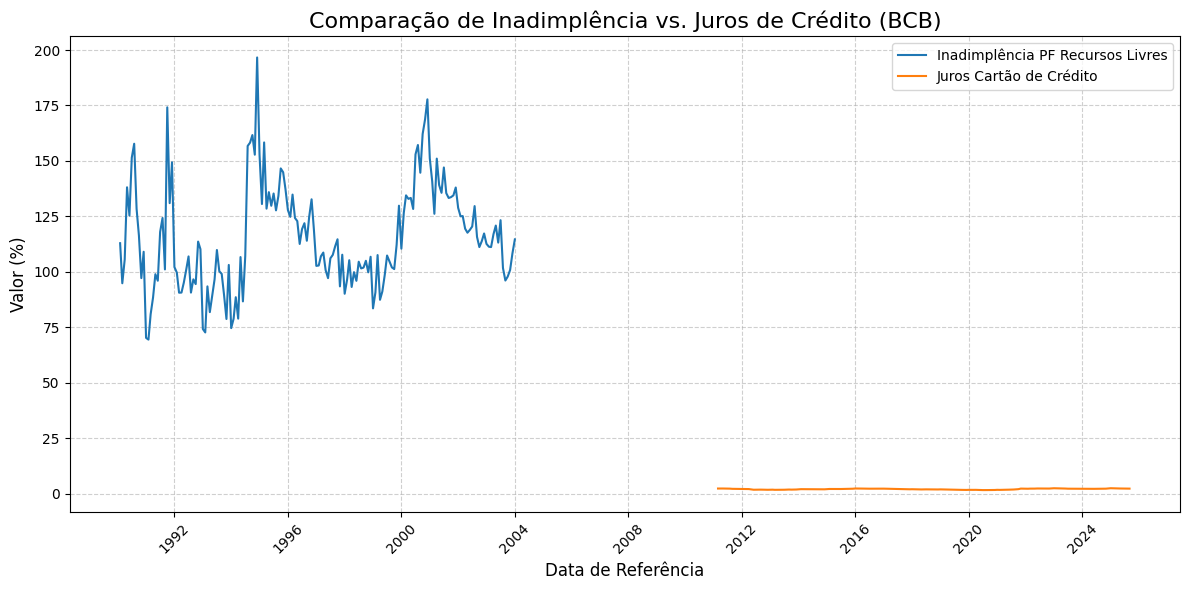

In [81]:

series_para_plotar = [
    'Inadimplência PF Recursos Livres',
    'Juros Cartão de Crédito'
]
df_plot = df[df['Nome_Indicador'].isin(series_para_plotar)]


fig, ax = plt.subplots()


for nome_indicador, dados in df_plot.groupby('Nome_Indicador'):
    ax.plot(
        dados['Data'],
        dados['Valor'],
        label=nome_indicador
    )


ax.set_title('Comparação de Inadimplência vs. Juros de Crédito (BCB)', fontsize=16)
ax.set_xlabel('Data de Referência', fontsize=12)
ax.set_ylabel('Valor (%)', fontsize=12)


plt.xticks(rotation=45)

ax.legend(loc='best')

ax.grid(True, linestyle='--', alpha=0.6)


plt.tight_layout()
plt.show()

 O Custo da Dívida vs. Referência


<BarContainer object of 1 artists>

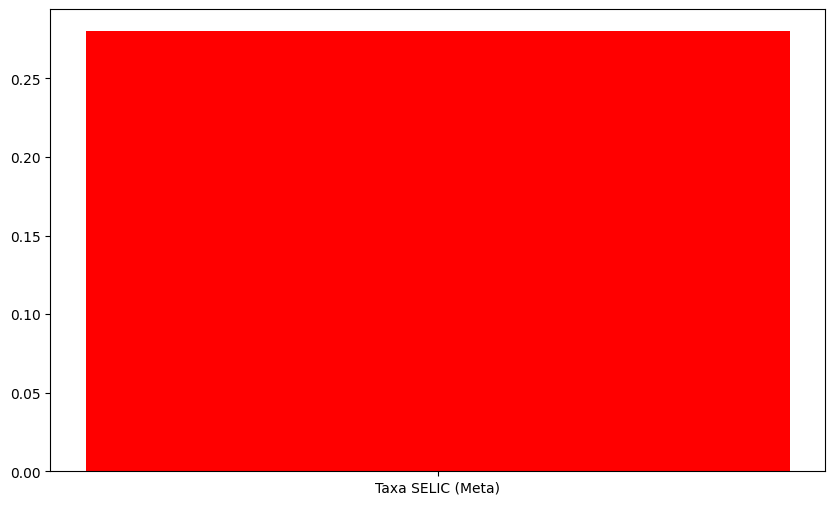

In [82]:

print(" O Custo da Dívida vs. Referência")


series_comparacao = [
    'Taxa SELIC (Meta)',
    'Juros Empréstimo Consignado',
    'Juros Cheque Especial',
    'Juros Cartão de Crédito'
]


ultima_data = df['Data'].max()


df_ultimos = df_ultimos.sort_values(by='Valor', ascending=False)


CORES_BARRAS = ['red', 'orange', 'blue', 'green']



plt.figure(figsize=(10, 6))

plt.bar(
    df_ultimos['Nome_Indicador'],
    df_ultimos['Valor'],
    color=CORES_BARRAS
)



Inflação vs. Poupança


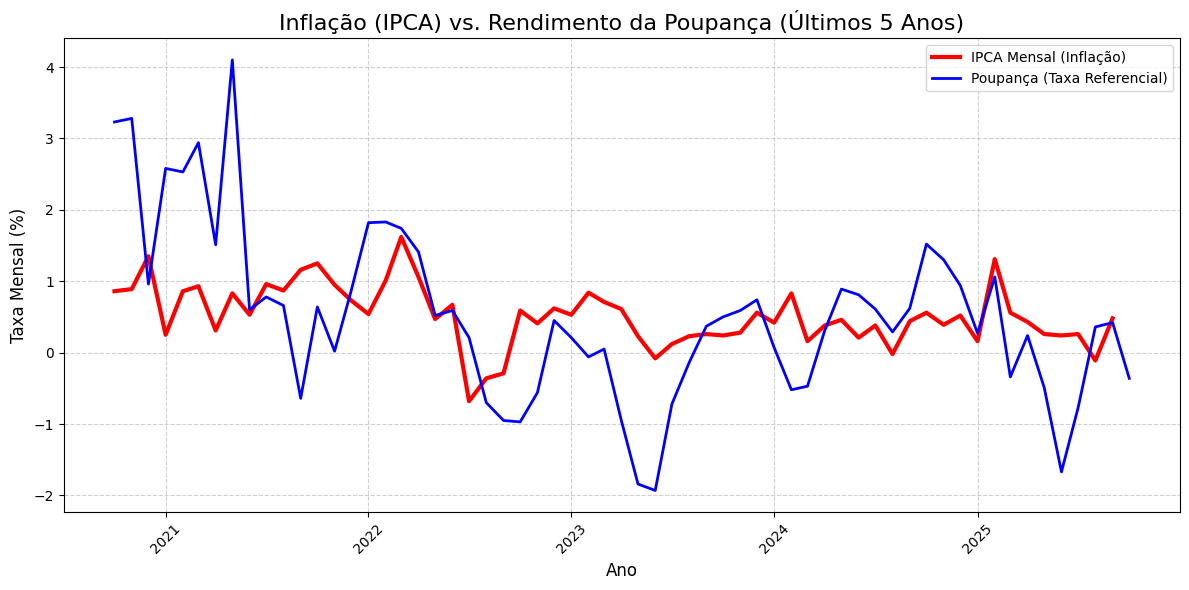

In [83]:

print("Inflação vs. Poupança")


series_comparacao_inflacao = [
    'IPCA Mensal (Inflação)',
    'Poupança (Taxa Referencial)'
]
df_plot_inflacao = df[df['Nome_Indicador'].isin(series_comparacao_inflacao)].copy()


data_limite = df_plot_inflacao['Data'].max() - pd.DateOffset(years=5)
df_plot_inflacao = df_plot_inflacao[df_plot_inflacao['Data'] >= data_limite]



fig, ax = plt.subplots(figsize=(12, 6))

for nome_indicador, dados in df_plot_inflacao.groupby('Nome_Indicador'):

    linewidth = 3 if 'IPCA' in nome_indicador else 2
    color = 'red' if 'IPCA' in nome_indicador else 'blue'

    ax.plot(
        dados['Data'],
        dados['Valor'],
        label=nome_indicador,
        linewidth=linewidth,
        color=color
    )


ax.set_title('Inflação (IPCA) vs. Rendimento da Poupança (Últimos 5 Anos)', fontsize=16)
ax.set_xlabel('Ano', fontsize=12)
ax.set_ylabel('Taxa Mensal (%)', fontsize=12)

plt.xticks(rotation=45)
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

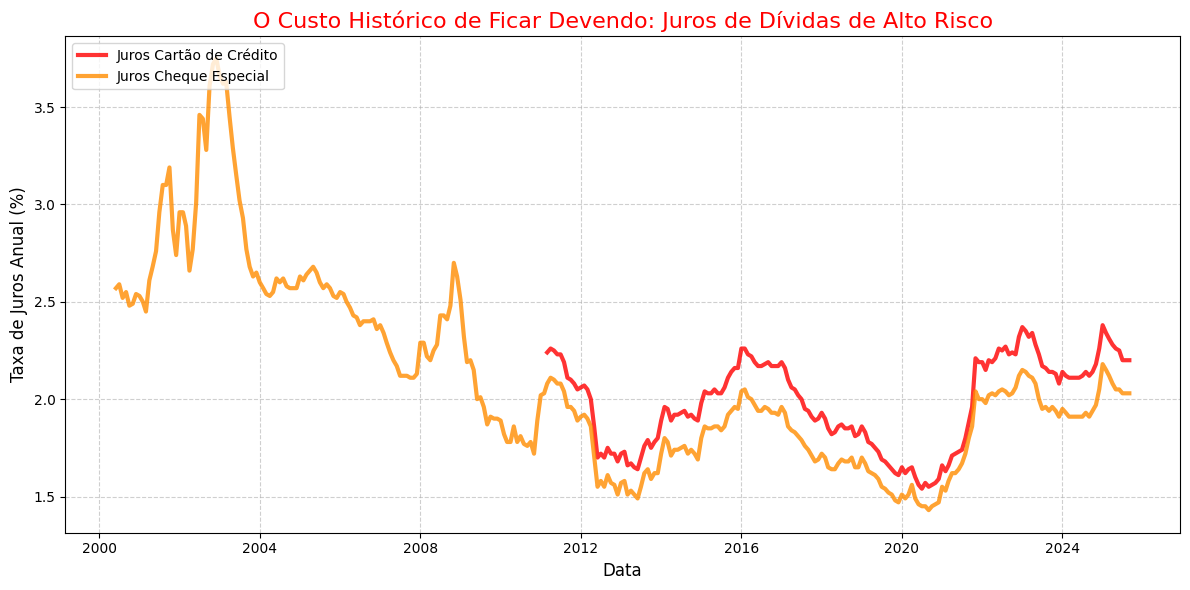

In [84]:
import matplotlib.pyplot as plt
import pandas as pd


series_divida_alta = ['Juros Cartão de Crédito', 'Juros Cheque Especial']
df_divida = df[df['Nome_Indicador'].isin(series_divida_alta)].copy()


plt.rcParams['figure.figsize'] = (12, 6)
fig, ax = plt.subplots()

for nome_indicador, dados in df_divida.groupby('Nome_Indicador'):

    cor = 'red' if 'Cartão de Crédito' in nome_indicador else 'darkorange'
    ax.plot(
        dados['Data'],
        dados['Valor'],
        label=nome_indicador,
        color=cor,
        linewidth=3,
        alpha=0.8
    )

ax.set_title('O Custo Histórico de Ficar Devendo: Juros de Dívidas de Alto Risco', fontsize=16, color='red')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Taxa de Juros Anual (%)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

KeyError: 'Taxa de Câmbio Dólar (Venda - Livre)'

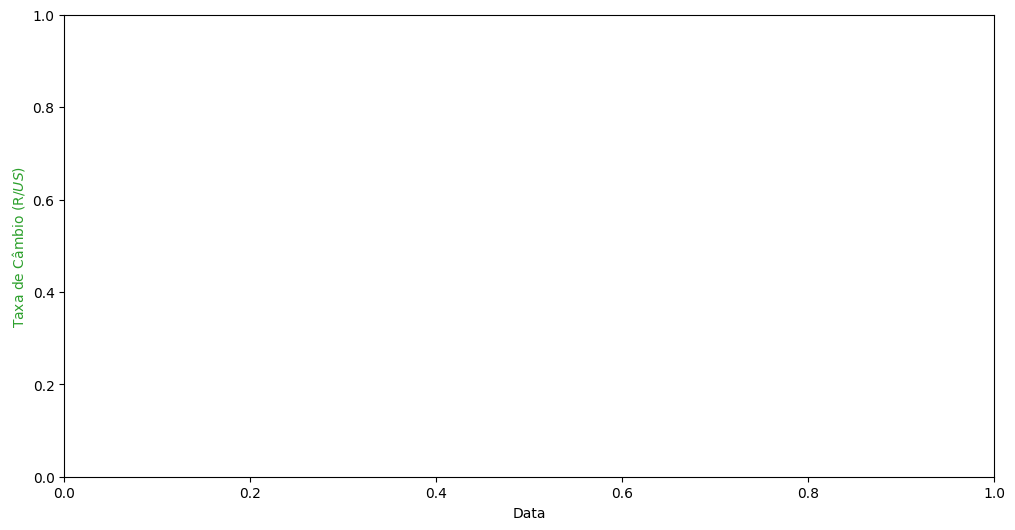

In [85]:
NOME_DOLAR = 'Taxa de Câmbio Dólar (Venda - Livre)'
NOME_CONFIANCA = 'Índice de Confiança do Empresário'


df_mercado = df[df['Nome_Indicador'].isin([NOME_DOLAR, NOME_CONFIANCA])].copy()


df_pivot = df_mercado.pivot_table(index='Data', columns='Nome_Indicador', values='Valor').dropna()


fig, ax1 = plt.subplots(figsize=(12, 6))


cor_dolar = 'tab:green'
ax1.set_xlabel('Data')
ax1.set_ylabel('Taxa de Câmbio (R$/US$)', color=cor_dolar)

ax1.plot(df_pivot.index, df_pivot[NOME_DOLAR], color=cor_dolar, label='Dólar (Eixo Esquerdo)')
ax1.tick_params(axis='y', labelcolor=cor_dolar)


ax2 = ax1.twinx()
cor_confianca = 'tab:orange'
ax2.set_ylabel('Confiança (Pontos)', color=cor_confianca)

ax2.plot(df_pivot.index, df_pivot[NOME_CONFIANCA], color=cor_confianca, linestyle='--', label='Confiança (Eixo Direito)')
ax2.tick_params(axis='y', labelcolor=cor_confianca)


plt.title('Risco de Mercado: Dólar vs. Confiança do Empresário', fontsize=16)
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))
ax1.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

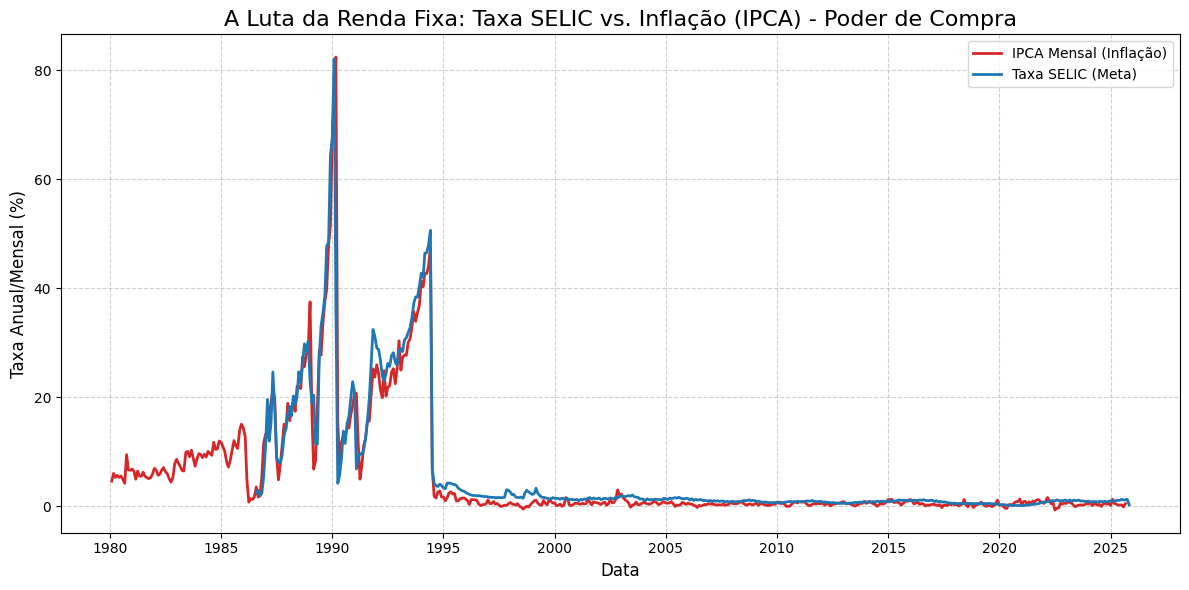

In [86]:



series_juro_real = ['Taxa SELIC (Meta)', 'IPCA Mensal (Inflação)']
df_juros = df[df['Nome_Indicador'].isin(series_juro_real)].copy()


plt.rcParams['figure.figsize'] = (12, 6)
fig, ax = plt.subplots()


for nome_indicador, dados in df_juros.groupby('Nome_Indicador'):

    cor = 'tab:blue' if 'SELIC' in nome_indicador else 'tab:red'
    ax.plot(
        dados['Data'],
        dados['Valor'],
        label=nome_indicador,
        color=cor,
        linewidth=2
    )


ax.set_title('A Luta da Renda Fixa: Taxa SELIC vs. Inflação (IPCA) - Poder de Compra', fontsize=16)
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Taxa Anual/Mensal (%)', fontsize=12)
ax.legend(loc='best')
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()